In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv('weight-height.csv')

# Step1: Problem identification
         -  Regression
         -  Classification
         -  Clustering
         - etccc         

In [7]:
data.shape

(10000, 3)

In [8]:
data.columns

Index(['Gender', 'Height', 'Weight'], dtype='object')

In [9]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [11]:
data.Gender = data.Gender.apply(lambda x: 1 if x=='Male' else 0)

In [12]:
data.corr()

,Gender,Height,Weight
Gender,1.000000,0.691072,0.796723
Height,0.691072,1.000000,0.924756
Weight,0.796723,0.924756,1.000000


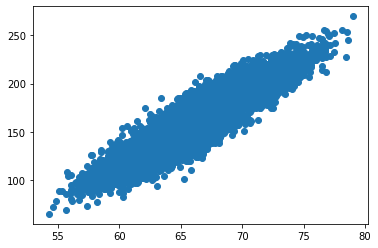

In [13]:
plt.scatter(x=data.Height, y=data.Weight)

# SIMPLE LINEAR REGRESSION MODEL: 
     Simple Linear Regression: we have only one predictor (X)    
      
     y = wx + b
     Weight = W(Height) + B

     Missing Parameters are : weight and bias 
     Our ML model will learn these paramter during training.
     We will then test the model on testing data.

# Step2: Separate input and output features. 
      Prtedictor (X)
      target     (y)

In [14]:
X= data[['Height']]
X.shape

(10000, 1)

In [15]:
y = data.Weight

# Step3: Splitting the data into training and testing sets

In [16]:
import sklearn

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step4: Model Selection:
          - Simple Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# Step5: Train the model / Fit the model

In [19]:
lr.fit(X_train,y_train)

LinearRegression()

In [20]:
lr.coef_

array([7.69542535])

In [132]:
lr.intercept_

np.float64(-349.32334860501635)

# Weight = W(Height) + B
# Weight  = 7.7(Height) - 350

# Step6: Prediction on trianing data

In [133]:
y_pred_train = lr.predict(X_train)

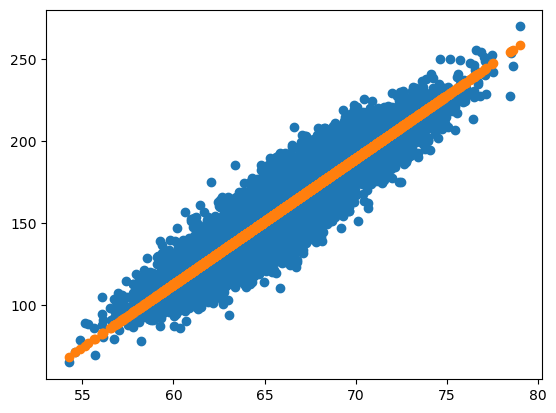

In [134]:
plt.scatter(x=X_train, y=y_train)
plt.scatter(x=X_train, y=y_pred_train)

# Step7: Model Performance Evaluation on training data

In [135]:
from sklearn.metrics import mean_squared_error, r2_score

In [136]:
mean_squared_error(y_train, y_pred_train)

149.7046382455686

In [137]:
r2_score(y_train, y_pred_train)

0.8539725668285366

# Step8: Model Performance Evaluation on testing  data


In [140]:
y_pred_test = lr.predict(X_test)

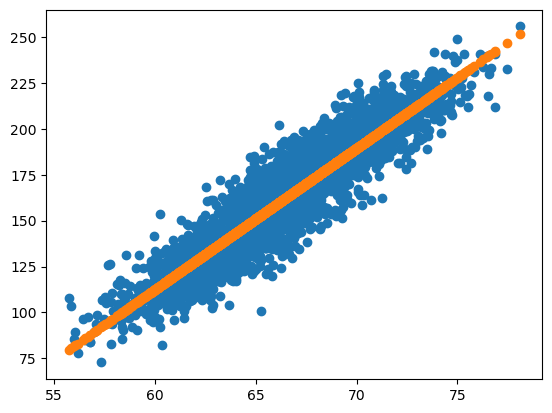

In [141]:
plt.scatter(x=X_test, y=y_test)
plt.scatter(x=X_test, y=y_pred_test)

In [142]:
mean_squared_error(y_test, y_pred_test)

148.36229532793996

In [143]:
r2_score(y_test, y_pred_test)

0.8577298529881874

In [144]:
height = float(input("Enter you height in ft")) * 12
lr.predict([[height]])

Enter you height in ft 8


C:\Users\Teacher\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([389.43748532])

In [145]:
X = data[['Gender', 'Height']]
# Simple Linear Rgression >>>> Multiple Linear Regression

In [146]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [147]:
lr2 = LinearRegression()

In [148]:
lr2.fit(X_train, y_train)

LinearRegression()

# Weight  = W1(Gender)+W2(Height)+B

In [149]:
lr2.coef_

array([19.40445243,  5.96180802])

In [150]:
lr2.intercept_


np.float64(-243.94905106192257)

# Weight  = W1(Gender)+W2(Height)+B
Weight  = 19.404 (Gender) + 5.96(Height) - 243.9

In [151]:
y_pred_train = lr2.predict(X_train)

In [152]:
r2_score(y_train, y_pred_train)

0.902443674513295

In [153]:
y_pred_test = lr2.predict(X_test)

In [154]:
r2_score(y_test, y_pred_test)

0.9033211309502138

In [155]:
gender  = int(input("Enter Gender"))
height = float(input("Enter you height in ft")) * 12
lr2.predict([[gender,height]])

Enter Gender 0
Enter you height in ft 5.6


C:\Users\Teacher\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([156.68444761])

In [156]:
import joblib

# Save your trained model to a file
joblib.dump(lr2, 'mlr.joblib')
joblib.dump(lr,'slr.joblib')

['slr.joblib']